# Software Development Lifecycle using Lang-Graph

In [102]:
import sys
print(sys.executable)

c:\Github\SDLC-using-Lang-Graph\env\Scripts\python.exe


In [103]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages

In [104]:
class State(TypedDict):
    messages : Annotated[list, add_messages]

In [105]:
import os
from dotenv import load_dotenv
load_dotenv()

True

In [106]:
from langchain_openai import ChatOpenAI

In [ ]:
llm = ChatOpenAI(
    model = "gpt-4.1-mini",
    temperature = 0.5)

In [108]:
from langchain_core.tools import tool
from langgraph.prebuilt import ToolNode
from langgraph.prebuilt import tools_condition
from langgraph.types import Command, interrupt
import datetime

In [163]:
from langgraph.checkpoint.memory import MemorySaver

memory = MemorySaver()
config = {"configurable": {"thread_id" : "11"}}

In [164]:
import sys
from pathlib import Path

# Go up one directory from "testing grounds" to the project root
project_root = Path.cwd().parent

sys.path.append(str(project_root))

In [165]:
import tools

In [166]:
tools_used = [tools.implementor.create_file, tools.implementor.update_file]

In [167]:
import importlib
import tools.implementor

importlib.reload(tools.implementor)

<module 'tools.implementor' from 'c:\\Github\\SDLC-using-Lang-Graph\\tools\\implementor.py'>

In [168]:
implementor = llm.bind_tools(tools = tools_used)

def implementing_agent(state:State):
    response = implementor.invoke(state["messages"])
    return {"messages": [response]}

In [169]:
graph_builder = StateGraph(State)

graph_builder.add_node("Implementor", implementing_agent)
graph_builder.add_node("tools", ToolNode(tools=tools_used))

graph_builder.add_edge(START, "Implementor")
graph_builder.add_conditional_edges(
    "Implementor",
    tools_condition
)
graph_builder.add_edge("tools", "Implementor")

graph = graph_builder.compile(checkpointer=memory)

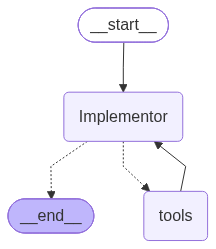

In [170]:
graph

from langchain_core.messages import HumanMessage

response = graph.invoke({"messages" : [
    HumanMessage(content="Implement this idea: I want to build a  tic tac toe game" \
    "which runs on webpages. I want the  game to follow general tic tac toe  rules " \
    "and  should display the score of the session and should be  refresed to 0-0 when  " \
    "a new session is made. The players should be able to name themselves. The scores of the game" \
    "should also be stored, you are free  to choose how they are stored again."),
    
]},config=config
)

for m  in response["messages"]:
    m.pretty_print()

from langchain_core.messages import HumanMessage

response = graph.invoke({"messages" : [
    HumanMessage(content="Implement  this  idea: int his application i want to have a button which " \
    "switcches the theme of the css from light mode to dark  mode  much  like how windows" \
    "provides either light mode or dark mode option again"),
    
]},config=config
)

response = graph.invoke({"messages" : [
    HumanMessage(content="Implement  this  idea: The change theme button doesnt work and when entering the players name make sure they are positioned properly, currently the player 2s name is blank on the 2nd line and the title 2nd player is on the first line"),
    
]},config=config
)

for m  in response["messages"]:
    m.pretty_print()

Implement a responsive landing page for a coffee shop.

Requirements:
- Create an index.html file.
- Create a styles.css file.
- Create a script.js file.
- The page should contain:
  - A navigation bar
  - A hero section
  - Three featured products
  - A footer
- The navigation bar should collapse into a hamburger menu on small screens.
- The JavaScript should implement the hamburger menu functionality.

In [177]:
prompt = f"""
Implement a responsive landing page for a coffee shop.

Requirements:
- Create an index.html file.
- Create a styles.css file.
- Create a script.js file.
- The page should contain:
  - A navigation bar
  - A hero section
  - Three featured products
  - A footer
- The navigation bar should collapse into a hamburger menu on small screens.
- The JavaScript should implement the hamburger menu functionality.
"""

In [178]:
from langchain_core.messages import HumanMessage

response = graph.invoke({"messages" : [
    HumanMessage(content=prompt),
    
]},config=config
)

Writing code into workspace\index.html......
Code succesfully written into workspace\index.html
Writing code into workspace\script.js......
Writing code into workspace\styles.css......
Code succesfully written into workspace\styles.css
Code succesfully written into workspace\script.js
